# Notebook 08: LangChain Multi-Agent Epidemic Decision System

This notebook introduces a LangChain-based multi-agent layer on top of the epidemic simulation design used in earlier notebooks.

## Goals
1. Build role-specialized agents with LangChain (policy, hospital coordination, communication).
2. Execute agent reasoning every 5 simulation steps for cost and latency control.
3. Keep execution compatible with Google Colab.
4. Produce interpretable decision logs and policy outcomes.

In [49]:
import os
import sys
import subprocess

COLAB = 'google.colab' in sys.modules
if COLAB:
    packages = [
    'mesa==2.3.2',
    'langchain==0.3.27',
    'langchain-community==0.3.27',
    'langchain-openai>=0.3.0',
    'langchain-google-genai>=2.0.0',
    'faiss-cpu==1.11.0.post1',
    'sentence-transformers>=3.0.0',
    'scikit-learn==1.7.1'
    ]
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + packages)

print('Environment ready. Colab mode:', COLAB)
print('Groq and Google providers are available via modular LLM config.')

Environment ready. Colab mode: True
Groq and Google providers are available via modular LLM config.


In [58]:
import os
from getpass import getpass

LLM_PROVIDER = os.getenv('LLM_PROVIDER', 'groq').strip().lower()
LLM_MODEL_ID = os.getenv('LLM_MODEL_ID', 'llama-3.3-70b-versatile').strip()
LLM_API_KEY = getpass('Enter API key for selected provider (required for LLM mode, blank = fallback mode): ').strip()
if not LLM_API_KEY:
    LLM_API_KEY = getpass('Enter API key for selected provider (required for LLM mode, blank = fallback mode): ').strip()

LLM_BASE_URLS = {
    'groq': 'https://api.groq.com/openai/v1',
    'openrouter': 'https://openrouter.ai/api/v1',
    'google': None
}
LLM_BASE_URL = LLM_BASE_URLS.get(LLM_PROVIDER)

if LLM_API_KEY:
    # Keep a generic key while also exposing common env names for compatibility.
    os.environ['LLM_API_KEY'] = LLM_API_KEY
    os.environ['OPENAI_API_KEY'] = LLM_API_KEY
    os.environ['OPENROUTER_API_KEY'] = LLM_API_KEY
    os.environ['GOOGLE_API_KEY'] = LLM_API_KEY
    os.environ['GROQ_API_KEY'] = LLM_API_KEY

print('Provider:', LLM_PROVIDER)
print('Model:', LLM_MODEL_ID)
print('LLM enabled:', bool(LLM_API_KEY))

Provider: groq
Model: llama-3.3-70b-versatile
LLM enabled: True


In [59]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mesa

from dataclasses import dataclass
from enum import Enum
from typing import Dict, List, Optional, Tuple

from sklearn.linear_model import LinearRegression
from scipy.signal import savgol_filter

from langchain.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain.text_splitter import RecursiveCharacterTextSplitter

try:
    from langchain_google_genai import ChatGoogleGenerativeAI
except Exception:
    ChatGoogleGenerativeAI = None

try:
    from langchain_openai import ChatOpenAI
except Exception:
    ChatOpenAI = None

plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (14, 10)
np.random.seed(42)

In [60]:
class State:
    SUSCEPTIBLE = 0
    INFECTED_UNTREATED = 1
    HOSPITALIZED = 2
    RECOVERED = 3

class PolicyType(Enum):
    SOCIAL_DISTANCING = 'social_distancing'
    ELECTIVE_SURGERY_BAN = 'elective_surgery_ban'
    MASK_MANDATE = 'mask_mandate'
    SCHOOL_CLOSURE = 'school_closure'
    INTER_HOSPITAL_TRANSFER = 'inter_hospital_transfer'
    CRISIS_STANDARDS = 'crisis_standards'
    RESOURCE_RATIONING = 'resource_rationing'

@dataclass
class Policy:
    policy_type: PolicyType
    active: bool
    effectiveness: float
    implementation_cost: int
    duration_steps: int
    description: str

@dataclass
class Prediction:
    target_metric: str
    current_value: float
    predicted_value: float
    prediction_horizon: int
    confidence: float

@dataclass
class Decision:
    step: int
    agent_name: str
    action: str
    confidence: float
    reasoning: str

class PolicyManager:
    def __init__(self):
        self.active_policies: Dict[PolicyType, Policy] = {}
        self.policy_history: List[Tuple[int, PolicyType, bool]] = []

    def activate_policy(self, policy: Policy, step: int):
        self.active_policies[policy.policy_type] = policy
        self.policy_history.append((step, policy.policy_type, True))

    def get_transmission_modifier(self) -> float:
        modifier = 1.0
        if PolicyType.SOCIAL_DISTANCING in self.active_policies:
            modifier *= 1 - self.active_policies[PolicyType.SOCIAL_DISTANCING].effectiveness
        if PolicyType.MASK_MANDATE in self.active_policies:
            modifier *= 1 - self.active_policies[PolicyType.MASK_MANDATE].effectiveness
        return modifier

    def get_hospital_capacity_modifier(self) -> float:
        modifier = 1.0
        if PolicyType.ELECTIVE_SURGERY_BAN in self.active_policies:
            modifier += self.active_policies[PolicyType.ELECTIVE_SURGERY_BAN].effectiveness
        return modifier

class PredictiveAnalytics:
    def __init__(self, history_window: int = 20):
        self.history_window = history_window

    def predict_hospital_demand(self, historical_data: pd.DataFrame, horizon: int = 5) -> Prediction:
        if len(historical_data) < self.history_window:
            return Prediction('hospital_demand', 0, 0, horizon, 0.5)

        recent_data = historical_data['Total Hospital Occupancy'].tail(self.history_window).values
        x_vals = np.arange(len(recent_data)).reshape(-1, 1)
        model = LinearRegression().fit(x_vals, recent_data)
        future_x = np.arange(len(recent_data), len(recent_data) + horizon).reshape(-1, 1)
        prediction = float(model.predict(future_x)[-1])

        volatility = float(np.std(np.diff(recent_data))) if len(recent_data) > 1 else 0.0
        confidence = max(0.3, 1.0 - volatility / max(1.0, recent_data[-1]))
        return Prediction('hospital_demand', float(recent_data[-1]), prediction, horizon, confidence)

    def predict_infection_peak(self, historical_data: pd.DataFrame) -> Prediction:
        if len(historical_data) < self.history_window:
            return Prediction('infection_peak', 0, 0, 10, 0.5)

        infected_total = (historical_data['Infected (Untreated)'] + historical_data['Hospitalized']).values
        if len(infected_total) < 11:
            current = float(infected_total[-1])
            return Prediction('infection_peak', current, current, 10, 0.4)

        smoothed = savgol_filter(infected_total, 11, 2)
        derivatives = np.diff(smoothed)
        trend = float(np.mean(derivatives[-5:])) if len(derivatives) >= 5 else 0.0
        current = float(infected_total[-1])

        if trend > 0:
            steps_to_peak = max(5, int(current / max(0.1, trend)))
            predicted_peak = current + trend * steps_to_peak
        else:
            steps_to_peak = 0
            predicted_peak = current

        confidence = 0.7 if abs(trend) > 1 else 0.4
        return Prediction('infection_peak', current, float(predicted_peak), steps_to_peak, confidence)

In [61]:
knowledge_docs = {
    'actionable_hospital_protocols.txt': '''
TRIGGER: Hospital occupancy > 80%
ACTIONS:
- ACTIVATE elective_surgery_ban (effectiveness: 0.25, cost: 100)
- INITIATE inter_hospital_transfer (effectiveness: 0.15, cost: 50)

TRIGGER: Hospital occupancy > 90%
ACTIONS:
- ACTIVATE crisis_standards (effectiveness: 0.20, cost: 200)
- IMPLEMENT resource_rationing (effectiveness: 0.10, cost: 150)
''',
    'community_intervention_protocols.txt': '''
TRIGGER: Untreated infected > 100 OR transmission rate > 0.4
ACTIONS:
- IMPLEMENT social_distancing (effectiveness: 0.35, cost: 300)
- ACTIVATE mask_mandate (effectiveness: 0.20, cost: 100)
''',
    'resource_optimization_protocols.txt': '''
TRIGGER: Multiple hospitals > 85% capacity
ACTIONS:
- COORDINATE inter_hospital_transfer (effectiveness: 0.25, cost: 100)

TRIGGER: Predicted ventilator shortage
ACTIONS:
- IMPLEMENT resource_rationing (effectiveness: 0.20, cost: 200)
'''
}

class EnhancedKnowledgeBase:
    def __init__(self, documents_path: str = 'knowledge_base_08'):
        os.makedirs(documents_path, exist_ok=True)
        for name, content in knowledge_docs.items():
            with open(os.path.join(documents_path, name), 'w', encoding='utf-8') as f:
                f.write(content)

        self.text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)
        self.embeddings = HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')

        docs = []
        for name in os.listdir(documents_path):
            if name.endswith('.txt'):
                with open(os.path.join(documents_path, name), 'r', encoding='utf-8') as f:
                    docs.append(Document(page_content=f.read(), metadata={'source': name}))

        chunks = self.text_splitter.split_documents(docs)
        self.vectorstore = FAISS.from_documents(chunks, self.embeddings)

    def search(self, query: str, k: int = 3) -> List[Document]:
        return self.vectorstore.similarity_search(query, k=k)

    def extract_actionable_policies(self, situation: str, k: int = 3) -> List[Policy]:
        results = self.search(situation, k=k)
        policies: List[Policy] = []
        for result in results:
            content = result.page_content
            if 'ACTIONS:' not in content:
                continue
            action_section = content.split('ACTIONS:')[1]
            lines = [ln.strip() for ln in action_section.split('\n') if ln.strip().startswith('- ')]
            for ln in lines:
                parsed = self.parse_action_line(ln)
                if parsed:
                    policies.append(parsed)
        return policies

    @staticmethod
    def parse_action_line(action_line: str) -> Optional[Policy]:
        mapping = {
            'elective_surgery_ban': PolicyType.ELECTIVE_SURGERY_BAN,
            'social_distancing': PolicyType.SOCIAL_DISTANCING,
            'mask_mandate': PolicyType.MASK_MANDATE,
            'school_closure': PolicyType.SCHOOL_CLOSURE,
            'crisis_standards': PolicyType.CRISIS_STANDARDS,
            'resource_rationing': PolicyType.RESOURCE_RATIONING,
            'inter_hospital_transfer': PolicyType.INTER_HOSPITAL_TRANSFER
        }

        policy_type = None
        for key, enum_val in mapping.items():
            if key in action_line:
                policy_type = enum_val
                break
        if not policy_type:
            return None

        effectiveness = 0.2
        cost = 100
        if 'effectiveness:' in action_line:
            effectiveness = float(action_line.split('effectiveness:')[1].split(',')[0].replace(')', '').strip())
        if 'cost:' in action_line:
            cost = int(action_line.split('cost:')[1].split(',')[0].replace(')', '').strip())

        return Policy(policy_type, False, effectiveness, cost, 20, action_line)

kb = EnhancedKnowledgeBase()
analytics = PredictiveAnalytics()
print('Knowledge base and predictive analytics ready.')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Knowledge base and predictive analytics ready.


In [62]:
class PersonAgent(mesa.Agent):
    def __init__(self, unique_id, model, recovery_rate, hospitalized_recovery_rate):
        super().__init__(unique_id, model)
        self.state = State.SUSCEPTIBLE
        self.recovery_rate = recovery_rate
        self.hospitalized_recovery_rate = hospitalized_recovery_rate
        self.hospital_id = None

    def step(self):
        effective_transmission = self.model.base_transmission_rate * self.model.policy_manager.get_transmission_modifier()

        if self.state == State.INFECTED_UNTREATED:
            self.try_to_get_hospitalized()
            self.infect_neighbors(effective_transmission)
            self.try_to_recover(self.recovery_rate)
        elif self.state == State.HOSPITALIZED:
            self.try_to_recover(self.hospitalized_recovery_rate)

        if self.state != State.HOSPITALIZED:
            self.move()

    def move(self):
        steps = self.model.grid.get_neighborhood(self.pos, moore=True)
        self.model.grid.move_agent(self, self.random.choice(steps))

    def infect_neighbors(self, transmission_rate):
        for other in self.model.grid.get_cell_list_contents([self.pos]):
            if isinstance(other, PersonAgent) and other.state == State.SUSCEPTIBLE:
                if self.random.random() < transmission_rate:
                    other.state = State.INFECTED_UNTREATED

    def try_to_recover(self, rate):
        if self.random.random() < rate:
            if self.state == State.HOSPITALIZED:
                hospital = next((h for h in self.model.hospitals if h.unique_id == self.hospital_id), None)
                if hospital:
                    hospital.discharge_patient()
                self.hospital_id = None
            self.state = State.RECOVERED

    def try_to_get_hospitalized(self):
        available_hospitals = [h for h in self.model.hospitals if not h.is_full]
        if not available_hospitals:
            return

        closest = min(available_hospitals, key=lambda h: abs(self.pos[0] - h.pos[0]) + abs(self.pos[1] - h.pos[1]))
        if self.pos == closest.pos:
            if closest.admit_patient():
                self.state = State.HOSPITALIZED
                self.hospital_id = closest.unique_id
        else:
            dx = closest.pos[0] - self.pos[0]
            dy = closest.pos[1] - self.pos[1]
            step = (self.pos[0] + int(np.sign(dx)), self.pos[1] + int(np.sign(dy)))
            step = (max(0, min(self.model.grid.width - 1, step[0])), max(0, min(self.model.grid.height - 1, step[1])))
            self.model.grid.move_agent(self, step)

class HospitalAgent(mesa.Agent):
    def __init__(self, unique_id, model, base_capacity=20):
        super().__init__(unique_id, model)
        self.base_capacity = base_capacity
        self.patients = 0

    @property
    def capacity(self):
        return int(self.base_capacity * self.model.policy_manager.get_hospital_capacity_modifier())

    @property
    def is_full(self):
        return self.patients >= self.capacity

    def admit_patient(self):
        if self.is_full:
            return False
        self.patients += 1
        return True

    def discharge_patient(self):
        if self.patients > 0:
            self.patients -= 1

    def step(self):
        return None

class IntelligentEpidemicModel(mesa.Model):
    def __init__(self, N=600, width=35, height=35, transmission_rate=0.45,
                 recovery_rate=0.04, hospitalized_recovery_rate=0.12,
                 p_initial_infected=0.03, num_hospitals=3, hospital_capacity=14):
        super().__init__()
        self.num_agents = N
        self.base_transmission_rate = transmission_rate
        self.grid = mesa.space.MultiGrid(width, height, True)
        self.schedule = mesa.time.RandomActivation(self)
        self.running = True
        self.hospitals = []
        self.policy_manager = PolicyManager()

        hospital_id_start = N + 1000
        for i in range(num_hospitals):
            h = HospitalAgent(hospital_id_start + i, self, hospital_capacity)
            self.hospitals.append(h)
            self.schedule.add(h)
            self.grid.place_agent(h, (self.random.randrange(width), self.random.randrange(height)))

        for i in range(N):
            person = PersonAgent(i, self, recovery_rate, hospitalized_recovery_rate)
            self.schedule.add(person)
            self.grid.place_agent(person, (self.random.randrange(width), self.random.randrange(height)))
            if self.random.random() < p_initial_infected:
                person.state = State.INFECTED_UNTREATED

        self.datacollector = mesa.DataCollector(model_reporters={
            'Susceptible': lambda m: self.count_states(m, PersonAgent, State.SUSCEPTIBLE),
            'Infected (Untreated)': lambda m: self.count_states(m, PersonAgent, State.INFECTED_UNTREATED),
            'Hospitalized': lambda m: self.count_states(m, PersonAgent, State.HOSPITALIZED),
            'Recovered': lambda m: self.count_states(m, PersonAgent, State.RECOVERED),
            'Total Hospital Occupancy': lambda m: sum(h.patients for h in m.hospitals),
            'Hospital Occupancy Rate': lambda m: (sum(h.patients for h in m.hospitals) / max(1, sum(h.capacity for h in m.hospitals))),
            'Active Policies': lambda m: len(m.policy_manager.active_policies),
            'Effective Transmission Rate': lambda m: m.base_transmission_rate * m.policy_manager.get_transmission_modifier(),
            'Effective Hospital Capacity': lambda m: sum(h.capacity for h in m.hospitals)
        })

    @staticmethod
    def count_states(model, agent_type, state):
        return sum(1 for a in model.schedule.agents if isinstance(a, agent_type) and a.state == state)

    def step(self):
        self.datacollector.collect(self)
        self.schedule.step()
        if self.count_states(self, PersonAgent, State.INFECTED_UNTREATED) == 0 and self.count_states(self, PersonAgent, State.HOSPITALIZED) == 0:
            self.running = False

print('Simulation classes ready.')

Simulation classes ready.


## LangChain Multi-Agent Layer

This orchestration includes three role agents:
- Policy Strategist: decides which policies to activate.
- Hospital Coordinator: suggests transfer plans.
- Public Communication Agent: generates concise executive summaries.

If Gemini credentials are unavailable, deterministic fallback logic is used so the notebook remains runnable.

In [66]:
class LangChainOrchestrator:
    def __init__(
        self,
        model: IntelligentEpidemicModel,
        kb: EnhancedKnowledgeBase,
        analytics: PredictiveAnalytics,
        llm_provider: str = 'groq',
        llm_model_id: str = 'llama-3.3-70b-versatile',
        llm_api_key: str = '',
        llm_base_url: Optional[str] = None,
        temperature: float = 0.2
    ):
        self.model = model
        self.kb = kb
        self.analytics = analytics
        self.decision_log: List[Decision] = []

        self.llm_provider = (llm_provider or '').strip().lower()
        self.llm_model_id = (llm_model_id or '').strip()
        self.llm_api_key = (llm_api_key or '').strip()
        self.llm_base_url = llm_base_url
        self.temperature = temperature

        self.has_llm = False
        self.llm = None
        self.policy_chain = None
        self.transfer_chain = None
        self.comms_chain = None

        if self.llm_api_key:
            self.llm = self._create_llm()
            self.has_llm = self.llm is not None

        if self.has_llm:
            self._build_chains()

    def _create_llm(self):
        if self.llm_provider == 'groq':
            if ChatOpenAI is None:
                print('Groq provider requested but langchain-openai is unavailable. Falling back to rule-based mode.')
                return None
            try:
                return ChatOpenAI(
                    model=self.llm_model_id,
                    api_key=self.llm_api_key,
                    base_url=self.llm_base_url or 'https://api.groq.com/openai/v1',
                    temperature=self.temperature
                )
            except Exception as exc:
                print(f'Groq LLM initialization failed: {exc}. Falling back to rule-based mode.')
                return None

        if self.llm_provider == 'openrouter':
            if ChatOpenAI is None:
                print('OpenRouter provider requested but langchain-openai is unavailable. Falling back to rule-based mode.')
                return None
            try:
                return ChatOpenAI(
                    model=self.llm_model_id,
                    api_key=self.llm_api_key,
                    base_url=self.llm_base_url or 'https://openrouter.ai/api/v1',
                    temperature=self.temperature
                )
            except Exception as exc:
                print(f'OpenRouter LLM initialization failed: {exc}. Falling back to rule-based mode.')
                return None

        if self.llm_provider == 'google':
            if ChatGoogleGenerativeAI is None:
                print('Google provider requested but langchain-google-genai is unavailable. Falling back to rule-based mode.')
                return None
            try:
                return ChatGoogleGenerativeAI(
                    model=self.llm_model_id,
                    google_api_key=self.llm_api_key,
                    temperature=self.temperature
                )
            except Exception as exc:
                print(f'Google LLM initialization failed: {exc}. Falling back to rule-based mode.')
                return None

        print(f'Unsupported provider: {self.llm_provider}. Falling back to rule-based mode.')
        return None

    def _build_chains(self):
        policy_prompt = ChatPromptTemplate.from_messages([
            ('system', 'You are a policy strategist for epidemic response. Return strict JSON list of policy names from this set: social_distancing, mask_mandate, elective_surgery_ban, crisis_standards, inter_hospital_transfer, resource_rationing, school_closure.'),
            ('human', 'State metrics: {metrics}. Predictions: {predictions}. Recommended actions: {kb_actions}. Return JSON like {{"policies":["social_distancing"]}}.')
        ])
        self.policy_chain = policy_prompt | self.llm | StrOutputParser()

        transfer_prompt = ChatPromptTemplate.from_messages([
            ('system', 'You coordinate hospital transfers. Return JSON object with keys from_hospital, to_hospital, count.'),
            ('human', 'Hospital occupancy list: {hospital_state}. Return JSON plan or empty plan with count 0.')
        ])
        self.transfer_chain = transfer_prompt | self.llm | StrOutputParser()

        comms_prompt = ChatPromptTemplate.from_messages([
            ('system', 'You produce one concise decision summary for leaders.'),
            ('human', 'Metrics: {metrics}. Decisions: {decisions}. Keep it short and factual.')
        ])
        self.comms_chain = comms_prompt | self.llm | StrOutputParser()

    def _metrics_snapshot(self) -> Dict[str, float]:
        total_hospitalized = sum(h.patients for h in self.model.hospitals)
        total_capacity = sum(h.capacity for h in self.model.hospitals)
        infected_untreated = self.model.count_states(self.model, PersonAgent, State.INFECTED_UNTREATED)
        return {
            'hospital_occupancy_rate': total_hospitalized / max(1, total_capacity),
            'total_hospitalized': total_hospitalized,
            'total_capacity': total_capacity,
            'infected_untreated': infected_untreated,
            'effective_transmission_rate': self.model.base_transmission_rate * self.model.policy_manager.get_transmission_modifier()
        }

    def _predictions_snapshot(self) -> Dict[str, Dict[str, float]]:
        if len(self.model.datacollector.model_vars) < 15:
            return {}
        df = self.model.datacollector.get_model_vars_dataframe()
        hosp = self.analytics.predict_hospital_demand(df)
        peak = self.analytics.predict_infection_peak(df)
        return {
            'hospital_demand': hosp.__dict__,
            'infection_peak': peak.__dict__
        }

    def _fallback_policy_selection(self, metrics: Dict[str, float], kb_policies: List[Policy]) -> List[str]:
        selected = []
        if metrics['hospital_occupancy_rate'] > 0.55:
            selected.extend(['elective_surgery_ban', 'inter_hospital_transfer'])
        if metrics['infected_untreated'] > 35 or metrics['effective_transmission_rate'] > 0.20:
            selected.extend(['social_distancing', 'mask_mandate'])

        selected.extend([p.policy_type.value for p in kb_policies[:2]])
        return list(dict.fromkeys(selected))

    def _parse_policy_output(self, text: str) -> List[str]:
        try:
            payload = json.loads(text)
            values = payload.get('policies', [])
            return [v for v in values if isinstance(v, str)]
        except Exception:
            return []

    def _policy_from_name(self, name: str) -> Optional[Policy]:
        mapping = {
            'social_distancing': (PolicyType.SOCIAL_DISTANCING, 0.30, 300),
            'mask_mandate': (PolicyType.MASK_MANDATE, 0.20, 120),
            'elective_surgery_ban': (PolicyType.ELECTIVE_SURGERY_BAN, 0.25, 100),
            'school_closure': (PolicyType.SCHOOL_CLOSURE, 0.20, 350),
            'inter_hospital_transfer': (PolicyType.INTER_HOSPITAL_TRANSFER, 0.10, 80),
            'crisis_standards': (PolicyType.CRISIS_STANDARDS, 0.15, 200),
            'resource_rationing': (PolicyType.RESOURCE_RATIONING, 0.10, 150)
        }
        if name not in mapping:
            return None
        policy_type, eff, cost = mapping[name]
        return Policy(policy_type, False, eff, cost, 20, f'Activated by orchestrator: {name}')

    def _apply_transfer_plan(self, transfer_plan: Dict[str, int]):
        src = transfer_plan.get('from_hospital', -1)
        dst = transfer_plan.get('to_hospital', -1)
        count = max(0, int(transfer_plan.get('count', 0)))

        if count == 0:
            return
        if src < 0 or dst < 0 or src >= len(self.model.hospitals) or dst >= len(self.model.hospitals):
            return

        source = self.model.hospitals[src]
        target = self.model.hospitals[dst]
        transferable = min(count, source.patients, max(0, target.capacity - target.patients))
        if transferable > 0:
            source.patients -= transferable
            target.patients += transferable

    def _fallback_transfer_plan(self) -> Dict[str, int]:
        occupancy = [(idx, h.patients / max(1, h.capacity)) for idx, h in enumerate(self.model.hospitals)]
        overloaded = sorted([x for x in occupancy if x[1] > 0.9], key=lambda x: x[1], reverse=True)
        available = sorted([x for x in occupancy if x[1] < 0.7], key=lambda x: x[1])
        if not overloaded or not available:
            return {'from_hospital': -1, 'to_hospital': -1, 'count': 0}
        return {'from_hospital': overloaded[0][0], 'to_hospital': available[0][0], 'count': 2}

    def evaluate_and_act(self, step: int, decision_threshold: float = 0.6):
        metrics = self._metrics_snapshot()
        predictions = self._predictions_snapshot()
        situation = f"Hospital occupancy {metrics['hospital_occupancy_rate']:.1%}. Untreated infected {metrics['infected_untreated']}."
        kb_policies = self.kb.extract_actionable_policies(situation, k=3)

        if self.has_llm:
            raw_policy = self.policy_chain.invoke({
                'metrics': json.dumps(metrics),
                'predictions': json.dumps(predictions),
                'kb_actions': [p.description for p in kb_policies]
            })
            policy_names = self._parse_policy_output(raw_policy)
        else:
            policy_names = self._fallback_policy_selection(metrics, kb_policies)

        for name in policy_names:
            candidate = self._policy_from_name(name)
            if candidate is None:
                continue
            if candidate.policy_type in self.model.policy_manager.active_policies:
                continue

            urgency = 0.0
            urgency += 0.5 if metrics['hospital_occupancy_rate'] > 0.85 else 0.0
            urgency += 0.3 if metrics['infected_untreated'] > 80 else 0.0
            urgency += 0.2 if metrics['effective_transmission_rate'] > 0.3 else 0.0
            score = min(1.0, urgency * 0.5 + candidate.effectiveness * 0.3 + (1 / (1 + candidate.implementation_cost / 100)) * 0.2)

            if score >= decision_threshold:
                self.model.policy_manager.activate_policy(candidate, step)
                reason = f"occupancy={metrics['hospital_occupancy_rate']:.2f}, infected={metrics['infected_untreated']}"
                self.decision_log.append(Decision(step, 'PolicyStrategist', f'ACTIVATE_{candidate.policy_type.value}', score, reason))

        if self.has_llm:
            hospital_state = [
                {'hospital_index': i, 'patients': h.patients, 'capacity': h.capacity} for i, h in enumerate(self.model.hospitals)
            ]
            raw_transfer = self.transfer_chain.invoke({'hospital_state': json.dumps(hospital_state)})
            try:
                transfer_plan = json.loads(raw_transfer)
            except Exception:
                transfer_plan = {'from_hospital': -1, 'to_hospital': -1, 'count': 0}
        else:
            transfer_plan = self._fallback_transfer_plan()

        self._apply_transfer_plan(transfer_plan)

        if self.has_llm:
            summary = self.comms_chain.invoke({'metrics': json.dumps(metrics), 'decisions': [d.action for d in self.decision_log[-3:]]})
        else:
            summary = f"Step {step}: occupancy={metrics['hospital_occupancy_rate']:.1%}, active_policies={len(self.model.policy_manager.active_policies)}"

        return summary

print('LangChain orchestrator ready.')

LangChain orchestrator ready.


In [67]:
POPULATION = 700
GRID_WIDTH = 35
GRID_HEIGHT = 35
BASE_TRANSMISSION_RATE = 0.9
RECOVERY_RATE = 0.04
HOSPITALIZED_RECOVERY_RATE = 0.05
INITIAL_INFECTED_P = 0.30
NUM_HOSPITALS = 3
HOSPITAL_CAPACITY = 14
SIMULATION_STEPS = 100
AGENT_INTERVAL = 5

model = IntelligentEpidemicModel(
    N=POPULATION,
    width=GRID_WIDTH,
    height=GRID_HEIGHT,
    transmission_rate=BASE_TRANSMISSION_RATE,
    recovery_rate=RECOVERY_RATE,
    hospitalized_recovery_rate=HOSPITALIZED_RECOVERY_RATE,
    p_initial_infected=INITIAL_INFECTED_P,
    num_hospitals=NUM_HOSPITALS,
    hospital_capacity=HOSPITAL_CAPACITY
)

orchestrator = LangChainOrchestrator(
    model,
    kb,
    analytics,
    llm_provider=LLM_PROVIDER,
    llm_model_id=LLM_MODEL_ID,
    llm_api_key=LLM_API_KEY,
    llm_base_url=LLM_BASE_URL,
    temperature=0.2
)
step_summaries = []

print(f"Runtime LLM mode: {'enabled' if orchestrator.has_llm else 'fallback'}")
print(f"Provider: {LLM_PROVIDER} | Model: {LLM_MODEL_ID}")

for step in range(SIMULATION_STEPS):
    if not model.running:
        print(f'Simulation ended early at step {step}.')
        break

    model.step()
    if step % AGENT_INTERVAL == 0:
        summary = orchestrator.evaluate_and_act(step, decision_threshold=0.35)
        step_summaries.append(summary)

results_df = model.datacollector.get_model_vars_dataframe()
decision_df = pd.DataFrame([d.__dict__ for d in orchestrator.decision_log]) if orchestrator.decision_log else pd.DataFrame()

print('Simulation complete.')
print('Decisions made:', len(orchestrator.decision_log))
print('Active policies at end:', len(model.policy_manager.active_policies))
if step_summaries:
    print('Last summary:', step_summaries[-1])

Runtime LLM mode: enabled
Provider: groq | Model: llama-3.3-70b-versatile
Simulation complete.
Decisions made: 0
Active policies at end: 0
Last summary: **Decision Summary:**
Hospital occupancy rate is at 16.7% (7/42). With 10 untreated infected individuals and a high transmission rate (0.9), consider implementing infection control measures and increasing hospital capacity utilization to mitigate the spread.


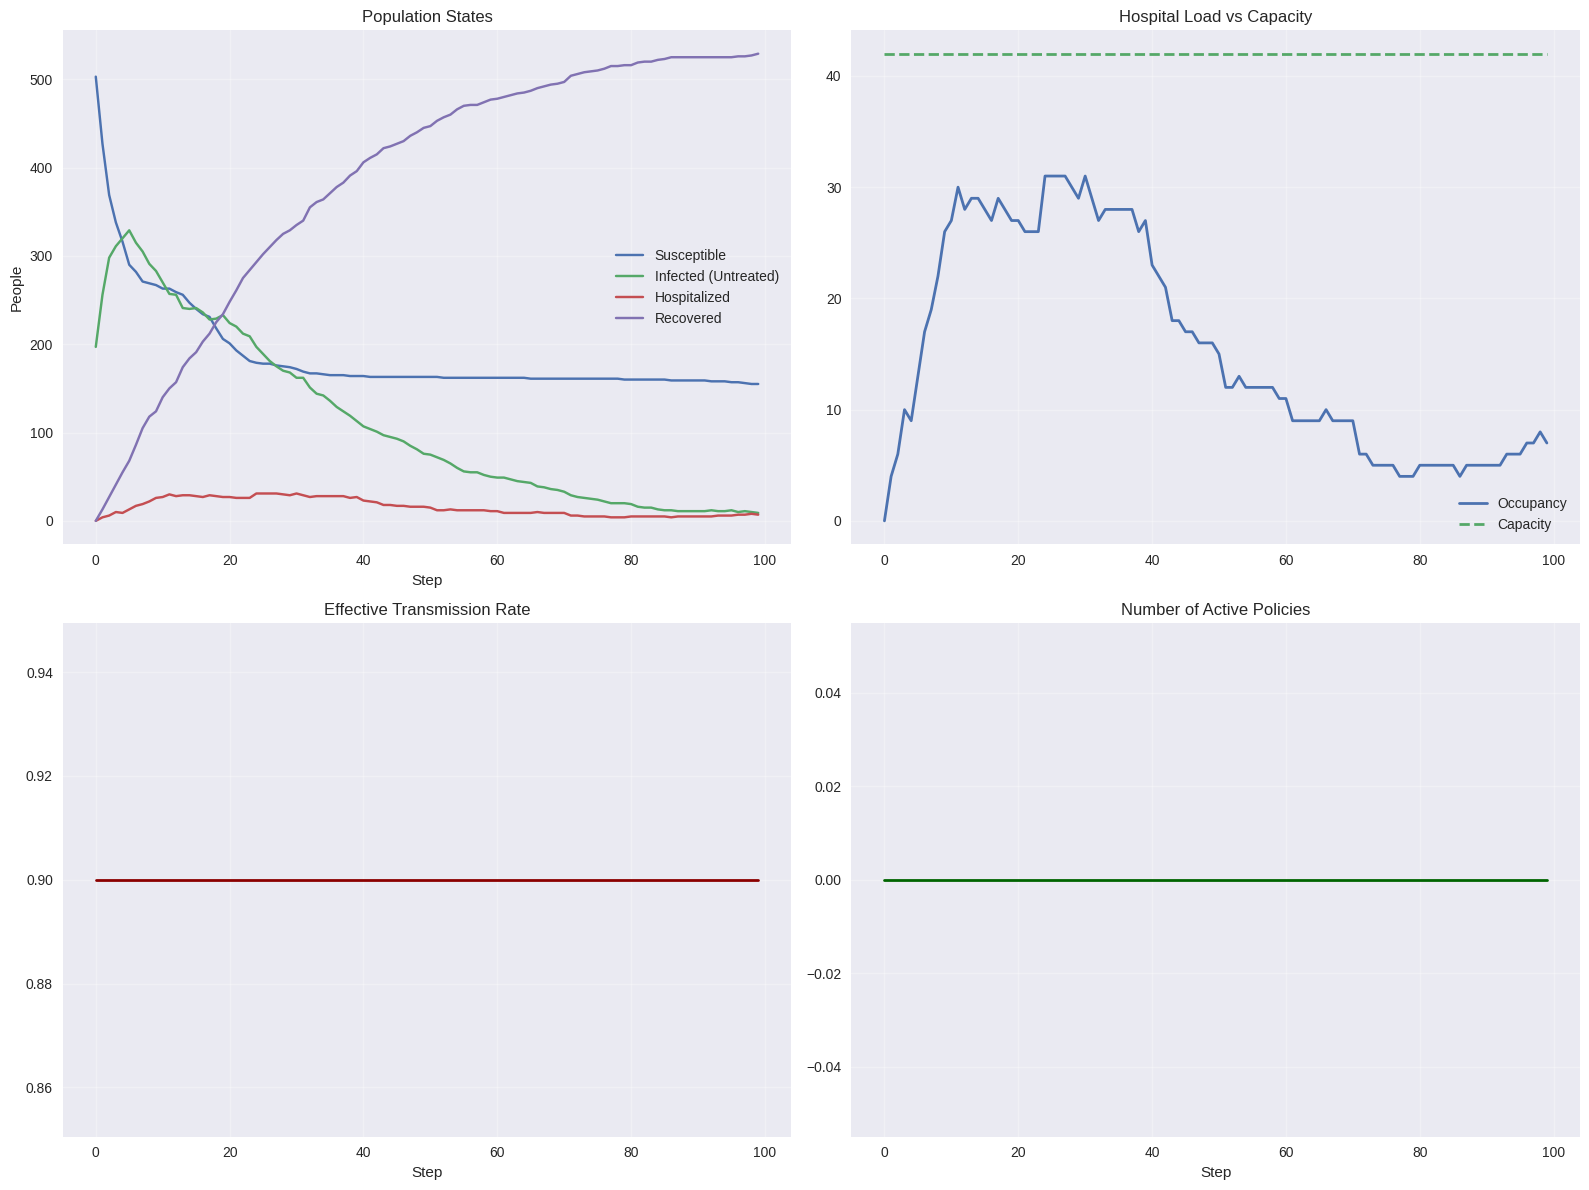

No policy activations were triggered in this run.


In [68]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

results_df[['Susceptible', 'Infected (Untreated)', 'Hospitalized', 'Recovered']].plot(ax=axes[0, 0], title='Population States')
axes[0, 0].set_xlabel('Step')
axes[0, 0].set_ylabel('People')

axes[0, 1].plot(results_df.index, results_df['Total Hospital Occupancy'], label='Occupancy', linewidth=2)
axes[0, 1].plot(results_df.index, results_df['Effective Hospital Capacity'], label='Capacity', linewidth=2, linestyle='--')
axes[0, 1].set_title('Hospital Load vs Capacity')
axes[0, 1].legend()

axes[1, 0].plot(results_df.index, results_df['Effective Transmission Rate'], color='darkred', linewidth=2)
axes[1, 0].set_title('Effective Transmission Rate')
axes[1, 0].set_xlabel('Step')

axes[1, 1].plot(results_df.index, results_df['Active Policies'], color='darkgreen', linewidth=2)
axes[1, 1].set_title('Number of Active Policies')
axes[1, 1].set_xlabel('Step')

for ax in axes.ravel():
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

if not decision_df.empty:
    print('Latest decisions:')
    display(decision_df.tail(10))
else:
    print('No policy activations were triggered in this run.')

## Advantages of LangChain Multi-Agent Design

1. Role specialization: each agent focuses on a narrow objective (policy, transfer, communication), which improves modularity.
2. Fast experimentation: prompt or tool updates can be tested quickly without rewriting the full simulation engine.
3. Explainability: decision logs plus generated summaries make interventions easier to audit.
4. Flexible fallback: when no API key is available, deterministic logic keeps the notebook runnable in class/lab settings.

## Limitations

1. Less deterministic than graph workflows when free-form LLM reasoning is enabled.
2. Runtime and cost depend on external model calls.
3. Guardrails and schema checks are still required to prevent noisy policy actions.